# 4 · Seed-ensemble: el modelo final

El VAE `recon_prob` era el mejor pero **cada semilla converge distinto** → varianza
alta. Solución: **seed-ensemble** — entrenar N VAEs con semillas distintas y **promediar
sus scores** (z-normalizados por miembro). El ruido idiosincrático se cancela.

In [1]:
import lab                      # utilidades: métricas y gráficos (experiments/lab.py)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import config, data
from src.models import (IsolationForestDetector, OneClassSVMDetector,
                        ZScoreDetector, MahalanobisDetector,
                        AEDetector, DenoisingAEDetector, VAEDetector,
                        EnsembleDetector, DeepODDetector)
plt.rcParams["figure.dpi"] = 110
SEEDS = lab.SEEDS            # 10 semillas del estudio. Bajalas (p. ej. [42,43,44])
print("semillas:", SEEDS)   # para un Run all más rápido; los números se mueven ±std

semillas: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]


In [2]:
panel_z = data.prepare()                         # panel + etiqueta z_rinde
ds   = data.build_crop_dataset(panel_z, "soja")  # split + normalización (soja)
dsm  = data.build_crop_dataset(panel_z, "maiz")  # idem maíz
print("soja  train:", ds.X_train.shape, "| test anómalas:", int(ds.y_test.sum()))
print("maíz  train:", dsm.X_train.shape, "| test anómalas:", int(dsm.y_test.sum()))

[data] dedup panel: 27862 -> 20755 filas (7107 duplicados espurios por lat/lon eliminados)


soja  train: (6143, 65) | test anómalas: 251
maíz  train: (8082, 65) | test anómalas: 344


## 4.1 · El seed-ensemble
`EnsembleDetector` toma una lista de detectores ya construidos, normaliza el score de cada
uno y los promedia. Cada miembro es un VAE con la config ganadora del nb 3. Armamos 10 con
semillas 42..51 — el ensemble está totalmente a la vista:

In [3]:
def make_ensemble(base_seed):
    miembros = [VAEDetector(hidden_dims=(128,64), latent_dim=24, beta=1.0, n_mc_samples=50,
                            score_mode="recon_prob", max_epochs=300, patience=30,
                            random_state=base_seed+i) for i in range(10)]   # 10 semillas
    return EnsembleDetector(miembros, normalize="zscore", combine="mean")

# ±std del ensemble = 5 réplicas con semillas base distintas (50 VAEs en total; tarda).
# Guardamos la réplica base=42 para reusarla en los gráficos de más abajo.
filas_ens, ens_soja = [], None
for base in [42, 52, 62, 72, 82]:
    ens = make_ensemble(base).fit(ds.X_train)
    filas_ens.append(lab.metrics(ens.score_samples(ds.X_test), ds.y_test))
    if base == 42: ens_soja = ens
print("VAE seed-ensemble ×10 (soja) — media±std de 5 réplicas:")
lab.mean_std(filas_ens)

VAE seed-ensemble ×10 (soja) — media±std de 5 réplicas:


pr_auc              0.626±0.016
roc_auc             0.766±0.011
prec_at_k           0.596±0.022
recall_at_contam    0.303±0.003
dtype: str

## 4.2 · La varianza se desploma y la media sube
Comparamos el ensemble contra un VAE single (una semilla) — mismo modelo base:

In [4]:
single = [lab.metrics(VAEDetector(hidden_dims=(128,64), latent_dim=24, beta=1.0, n_mc_samples=50,
              score_mode="recon_prob", max_epochs=300, patience=30, random_state=s)
              .fit(ds.X_train).score_samples(ds.X_test), ds.y_test) for s in SEEDS]
print("VAE single     :", lab.mean_std(single)["pr_auc"])
print("VAE seed-ens ×10:", lab.mean_std(filas_ens)["pr_auc"])

VAE single     : 0.585±0.044
VAE seed-ens ×10: 0.626±0.016


El desvío cae fuerte **y la media sube**: el promedio de scores independientes gana en
media y en el peor caso.

## 4.3 · El modelo final, en ambos cultivos
Reusamos la réplica base=42 en soja y entrenamos una en maíz, para los histogramas de score.

> Ojo: el número **oficial** es la media±std de 4.1. Acá `sc_soja` es de **una réplica
> concreta** (base=42): su PR-AUC puntual cae *dentro* de ese ±std — no es un modelo
> distinto ni mejor.

In [5]:
sc_soja = ens_soja.score_samples(ds.X_test)          # réplica base=42 (ya entrenada en 4.1)
ens_maiz = make_ensemble(42).fit(dsm.X_train)
sc_maiz = ens_maiz.score_samples(dsm.X_test)
print("soja (réplica 42):", {k: round(v,3) for k,v in lab.metrics(sc_soja, ds.y_test).items()})
print("maíz (réplica 42):", {k: round(v,3) for k,v in lab.metrics(sc_maiz, dsm.y_test).items()})

soja (réplica 42): {'pr_auc': 0.603, 'roc_auc': 0.755, 'prec_at_k': 0.586, 'recall_at_contam': 0.303}
maíz (réplica 42): {'pr_auc': 0.576, 'roc_auc': 0.723, 'prec_at_k': 0.552, 'recall_at_contam': 0.262}


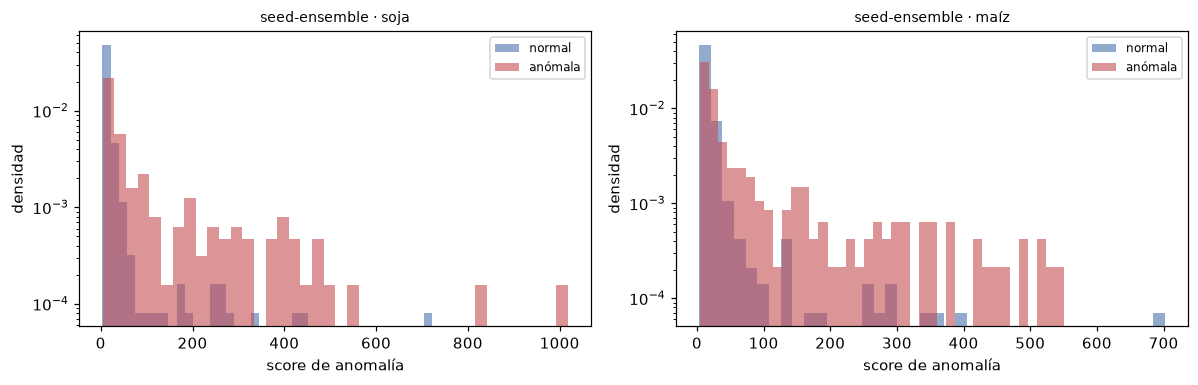

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.6))
lab.plot_scores(sc_soja, ds.y_test, ax=axs[0], titulo="seed-ensemble · soja")
lab.plot_scores(sc_maiz, dsm.y_test, ax=axs[1], titulo="seed-ensemble · maíz")
plt.tight_layout(); plt.show()

## 4.4 · Sobre el latente del ensemble
El latente del ensemble **es el del miembro 0 (VAE con seed 42), idéntico al del nb 3** —
mismo modelo, misma semilla, mismos datos. Ya lo analizamos ahí: IForest/OCSVM sobre ese
latente **no** superan al score directo, y su t-SNE muestra las anomalías mezcladas (sin
cluster). No lo repetimos acá para no duplicar el mismo gráfico.

**El seed-ensemble ×10 del VAE `recon_prob`** es el **modelo final**, con el menor desvío
entre semillas (ver la tabla de 4.1). Ni el latente + shallow lo supera. Corre sobre el panel
unificado (clima + NDVI + ERA5). En el nb 5 vemos por qué cuesta subir de acá (el techo) y en
el nb 6 chequeamos si las features agronómicas de dominio agregan algo más.